# Brazilian Amazon Rainforest Degradation 1999-2019

#### Author: William Wright
#### Credit: Mariana Boger Netto and Salma B for tutorial on code and visualizations!

# Setup 

In [149]:
!pip install seaborn -q
!pip install plotly -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats
import plotly.express as px
import os

# 1. Deforested Area Dataset Overview 

In [150]:
# Deforested dataset 
deforest_df = pd.read_csv('def_area_2004_2019.csv')
deforest_df.drop(['AMZ LEGAL'], axis=1, inplace=True)

In [151]:
deforest_df.head()

,Ano/Estados,AC,AM,AP,MA,MT,PA,RO,RR,TO
0,2004,728,1232,46,755,11814,8870,3858,311,158
1,2005,592,775,33,922,7145,5899,3244,133,271
2,2006,398,788,30,674,4333,5659,2049,231,124
3,2007,184,610,39,631,2678,5526,1611,309,63
4,2008,254,604,100,1271,3258,5607,1136,574,107


#### Plot deforested area for each state over time 

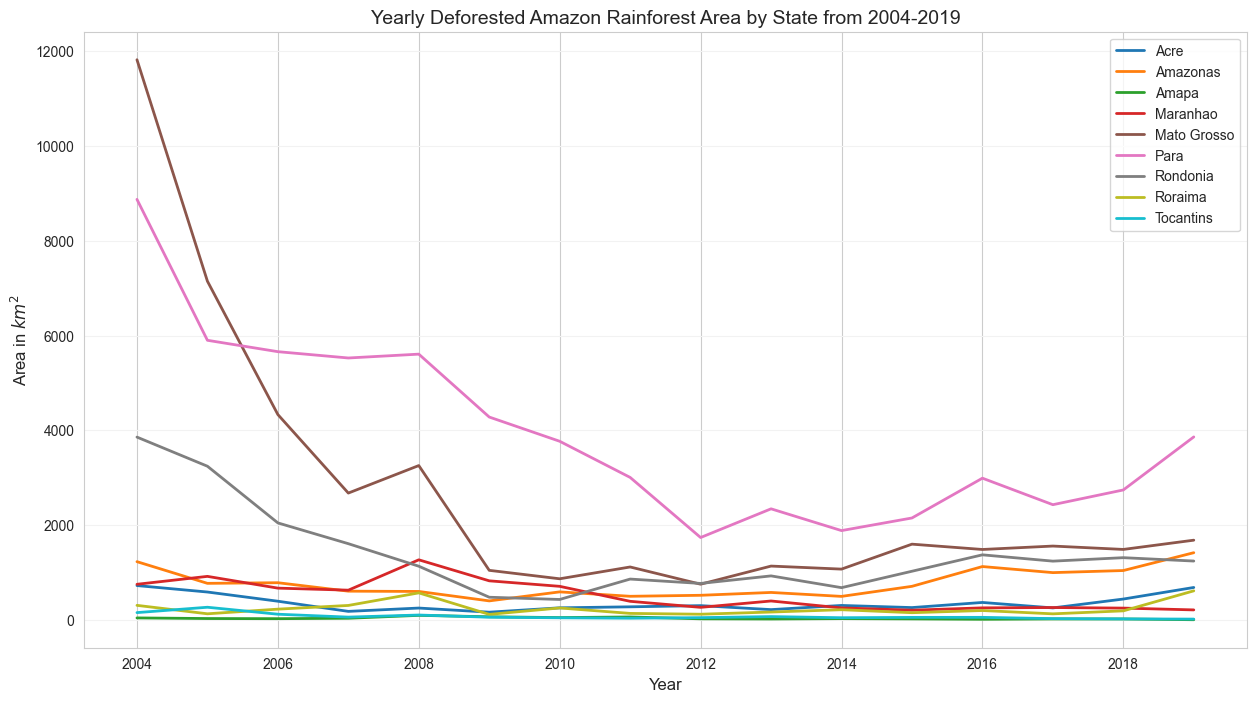

In [152]:
fig, ax = plt.subplots(figsize=(15,8))
states = ['Acre', 'Amazonas', 'Amapa', 'Maranhao', 'Mato Grosso', 'Para', 'Rondonia', 'Roraima', 'Tocantins']
deforest_df.plot(x='Ano/Estados', y=deforest_df.columns[1:10], 
                 label=states , colormap='tab10', linewidth=2, ax=ax)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area in $km^2$', fontsize=12)
ax.set_title('Yearly Deforested Amazon Rainforest Area by State from 2004-2019', fontsize=14)
ax.grid(axis='y', color='0.95')

#### 2004 was especially bad in the states of Para and Rondonia. This pattern followed a “fishbone” road-clearing trajectory: roads opened up remote forest, smallholders cleared for crops, degraded land was converted to pasture, and eventually consolidated into large cattle ranches ([NASA](https://svs.gsfc.nasa.gov/10872)). Here we plot each state on a separate graph with an orange line to highlight the cumulative sum of deforestated area over time.

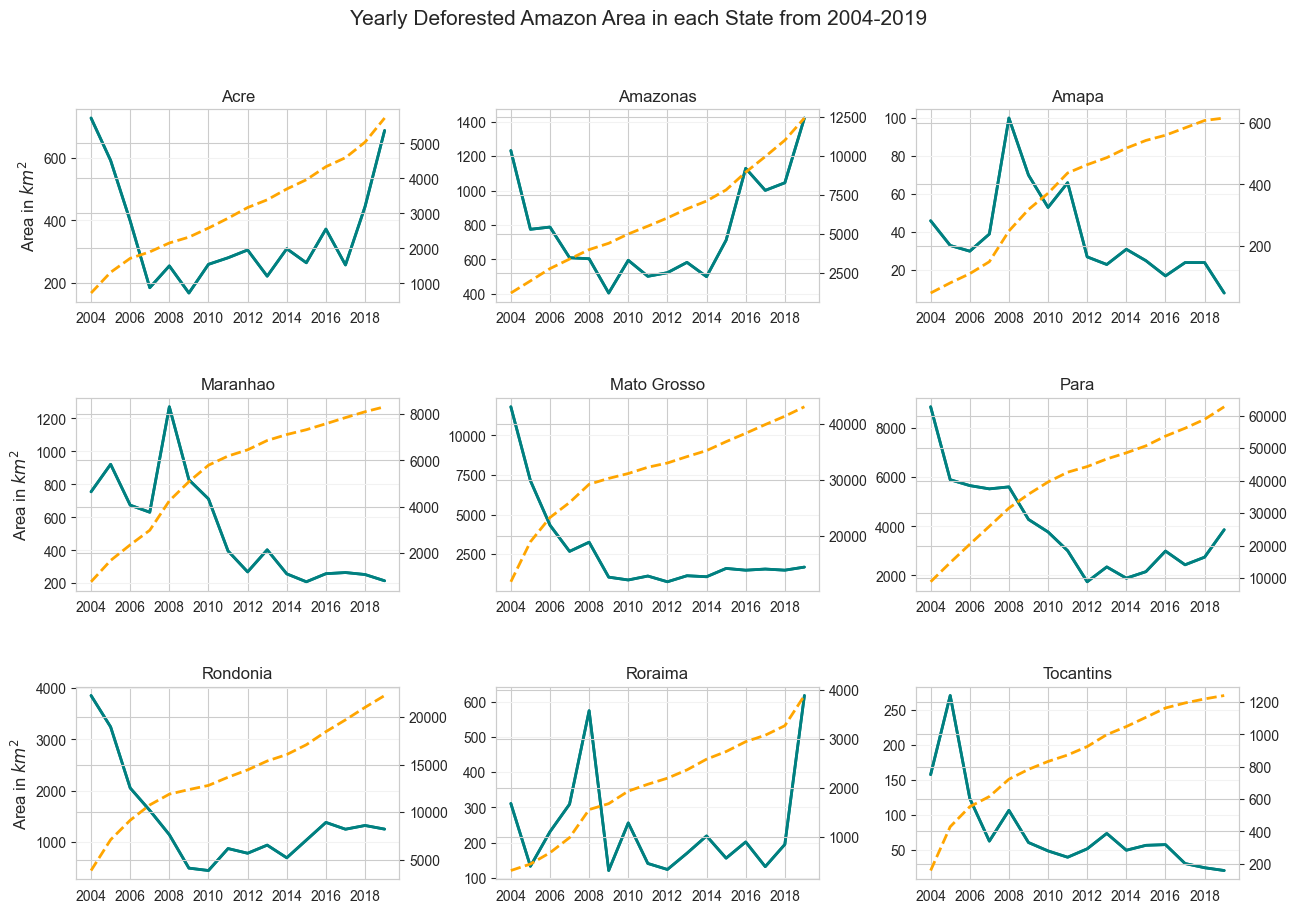

In [153]:
fig, ax = plt.subplots(3, 3, figsize=(15,10))
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.suptitle('Yearly Deforested Amazon Area in each State from 2004-2019', fontsize=15)
col_names = deforest_df.columns[1:10]
for i in range(3):
    for j in range(3):
        col = col_names[i*3+j]
        ax[i,j].plot(deforest_df['Ano/Estados'], deforest_df[col], linewidth=2, color='teal')
        ax[i,j].set_ylabel('Area in $km^2$', fontsize=12)
        ax[i,j].set_title(states[i*3+j])
        ax[i,j].grid(axis='y', color='0.95')
        ax[i,j].xaxis.set_major_locator(MaxNLocator(integer=True))
        if (j>0):
             ax[i,j].set(ylabel='')


# Added an additional feature to the original code to highlight the cumulative s
for i in range(3):
    for j in range(3):
        col = col_names[i*3+j]

        x = deforest_df['Ano/Estados']
        y = deforest_df[col]

        ax2 = ax[i,j].twinx()

        # Yearly
        ax[i,j].plot(x, y, color='teal', linewidth=2)

        # Cumulative
        ax2.plot(x, y.cumsum(), color='orange', linestyle='--', linewidth=2)

        ax[i,j].set_title(states[i*3+j])
        ax[i,j].grid(axis='y', color='0.95')

        if j > 0:
            ax[i,j].set(ylabel='')

            

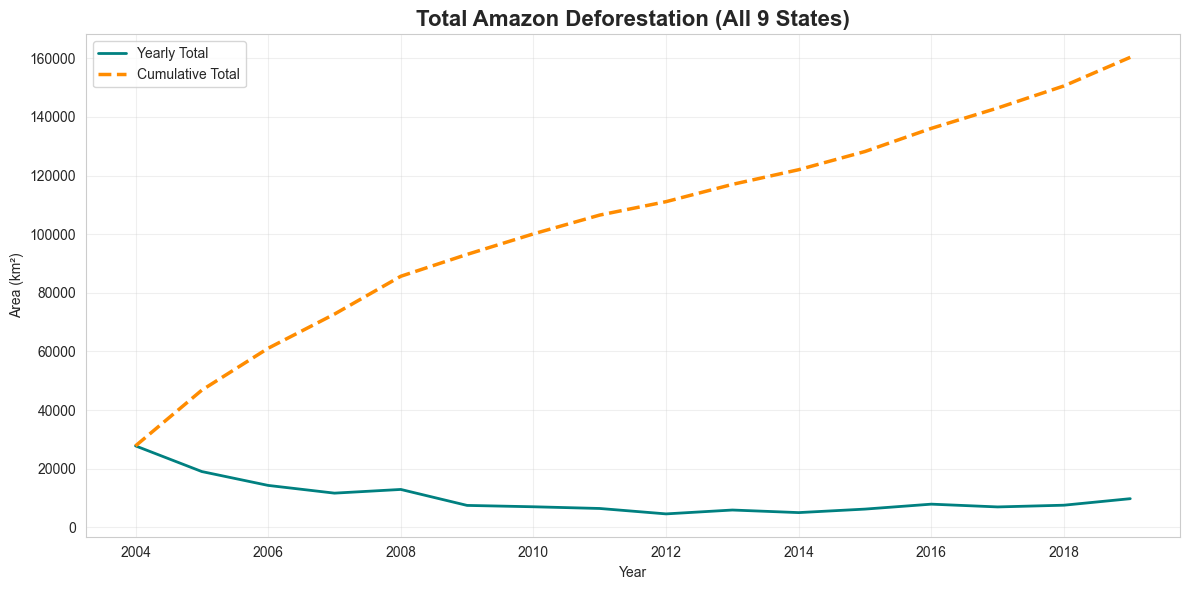

In [154]:
deforest_df['Total'] = deforest_df[col_names].sum(axis=1)
deforest_df['Total_cumsum'] = deforest_df['Total'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))

x = deforest_df['Ano/Estados']

# Yearly total
ax.plot(x, deforest_df['Total'], label='Yearly Total', color='teal', linewidth=2)

# Cumulative total
ax.plot(x, deforest_df['Total_cumsum'],
        label='Cumulative Total',
        linestyle='--',
        color='darkorange',
        linewidth=2.5)

ax.set_title('Total Amazon Deforestation (All 9 States)', fontsize=16, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Area (km²)')
ax.legend()
ax.grid(alpha=0.3)

final_val = y.iloc[-1]

plt.tight_layout()

#### Here we determine which state has exhibited the most deforestation since 2004

9 9


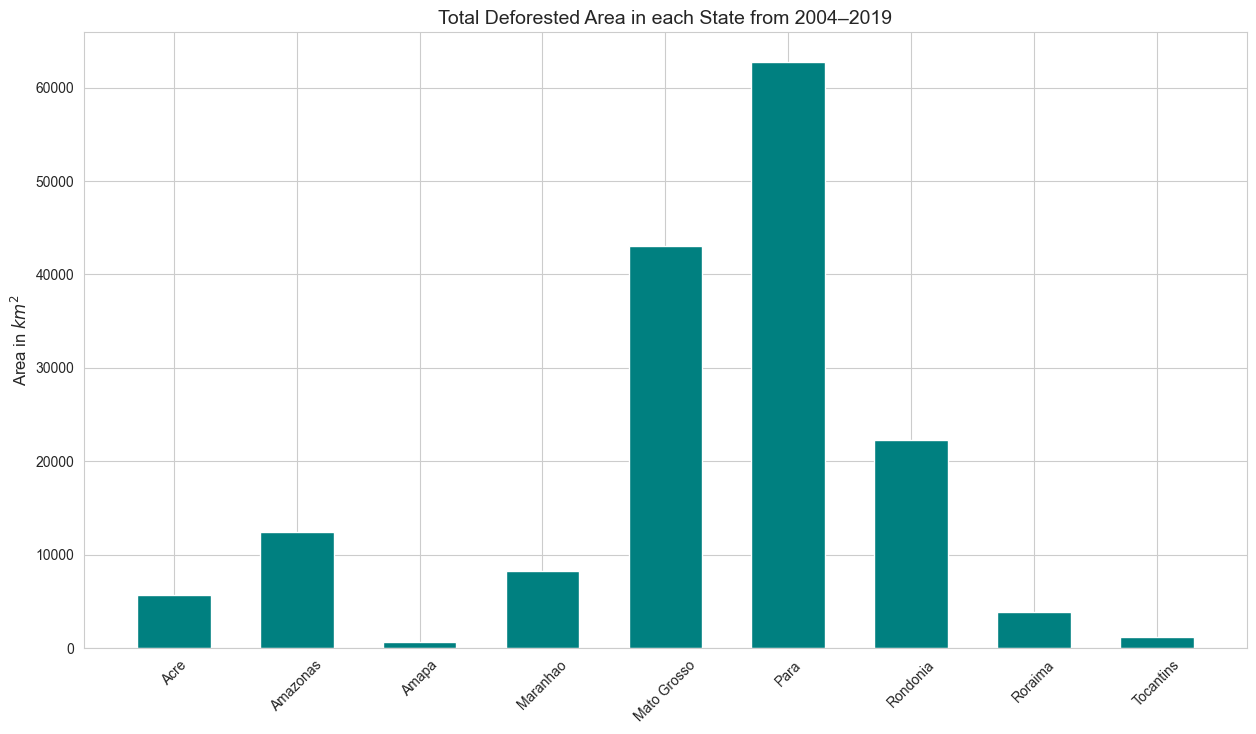

In [155]:
fig, ax = plt.subplots(figsize=(15,8))

# Only use the 9 state columns
totals = deforest_df[col_names].sum()

# Make sure lengths match
print(len(states), len(totals))  # should both be 9

ax.bar(states, totals.values, width=0.6, color='teal')

ax.set_ylabel('Area in $km^2$', fontsize=12)
ax.set_title('Total Deforested Area in each State from 2004–2019', fontsize=14)

plt.xticks(rotation=45)
plt.show()

# 2. El Nino and La Nina 

#### Now we'll look into El Nino and La Nina patterns and then compare them to deforested areas and eventually fire events to see if there are any correlations. The El Nino phenomenon sees warmer-than-average sea surface temperatures and weaker east winds while the La Nina phenomenon sees cooler-than-average sea surface temperatures and stronger east winds. Weather Patterns: El Niño typically causes increased rainfall in the eastern Pacific and drier conditions in the western Pacific, while La Niña often leads to opposite effects, with drier conditions in the eastern Pacific and increased rainfall in the western Pacific ([Own Your Weather](https://ownyourweather.com/difference-between-el-nino-and-la-nina/)).

In [156]:
climate_df = pd.read_csv('el_nino_la_nina_1999_2019.csv')
climate_df.head()

,start year,end year,phenomenon,severity
0,2004,2005,El Nino,Weak
1,2006,2007,El Nino,Weak
2,2014,2015,El Nino,Weak
3,2018,2019,El Nino,Weak
4,2002,2003,El Nino,Moderate


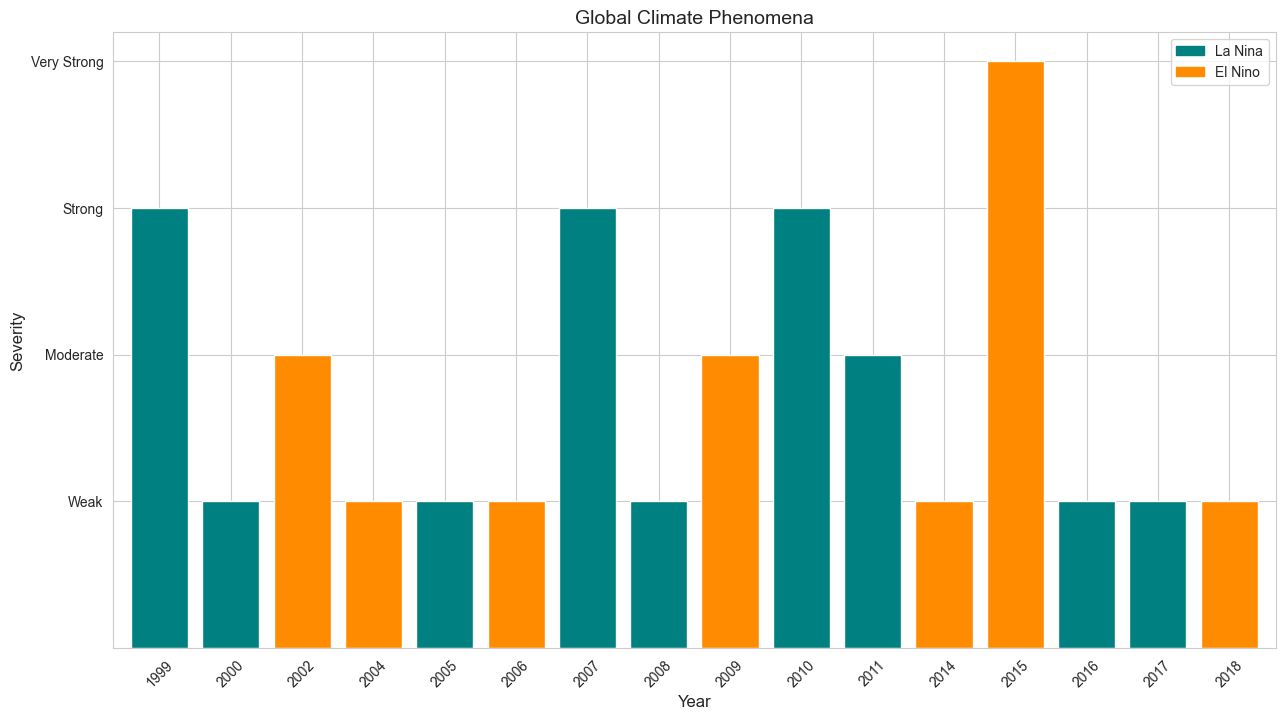

In [157]:
fig, ax = plt.subplots(figsize=(15,8))
height_map = {'Weak': 1, 'Moderate': 2, 'Strong': 3, 'Very Strong': 4}
climate_df['severity_height'] = climate_df['severity'].map(height_map)
climate_df.sort_values(by='start year', inplace=True)
colors = {'La Nina': 'teal', 'El Nino': 'darkorange'}
climate_df.plot.bar(x='start year', y='severity_height', 
                    yticks=range(1,5,1), width = 0.8,  
                    color=climate_df['phenomenon'].replace(colors), rot=45, ax=ax)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Severity', fontsize=12)
ax.set_title('Global Climate Phenomena', fontsize=14)
ax.set_yticklabels(height_map.keys())
labels = ['La Nina', 'El Nino']
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
ax.legend(handles, labels)
plt.show()

# 3. Fire Outbreaks

#### Now we analyze the firespots data for the 9 states. 

In [158]:
fires_df = pd.read_csv('inpe_brazilian_amazon_fires_1999_2019.csv')
fires_df.head()

,year,month,state,latitude,longitude,firespots
0,1999,1,AMAZONAS,-2.371113,-59.899933,3
1,1999,1,MARANHAO,-2.257395,-45.487831,36
2,1999,1,MATO GROSSO,-12.660633,-55.057989,18
3,1999,1,PARA,-2.474820,-48.546967,87
4,1999,1,RONDONIA,-12.861700,-60.513100,1


#### Let's make a map!

In [159]:
import pandas as pd
import geopandas as gpd

# Convert fires_df to GeoDataFrame as gdf while preserving fires_df
gdf = gpd.GeoDataFrame(fires_df, geometry=gpd.points_from_xy(fires_df.longitude, fires_df.latitude), crs="EPSG:4326")

gdf.head()


,year,month,state,latitude,longitude,firespots,geometry
0,1999,1,AMAZONAS,-2.371113,-59.899933,3,POINT (-59.89993 -2.37111)
1,1999,1,MARANHAO,-2.257395,-45.487831,36,POINT (-45.48783 -2.25739)
2,1999,1,MATO GROSSO,-12.660633,-55.057989,18,POINT (-55.05799 -12.66063)
3,1999,1,PARA,-2.474820,-48.546967,87,POINT (-48.54697 -2.47482)
4,1999,1,RONDONIA,-12.861700,-60.513100,1,POINT (-60.5131 -12.8617)


#### Static heat map using Folium 

In [160]:
!pip install folium -q
import folium
from folium.plugins import HeatMap

# Center map roughly over Brazil
m = folium.Map(location=[-10, -55], zoom_start=4)

heat_data = [
    [row['latitude'], row['longitude'], row['firespots']]
    for _, row in fires_df.iterrows()
]

HeatMap(heat_data).add_to(m)

m

#### Interactive heat map using Folium 

In [161]:
fires_df['time'] = pd.to_datetime(fires_df[['year','month']].assign(day=1))

from folium.plugins import HeatMapWithTime

# group by time
fires_df_sorted = fires_df.sort_values('time')

grouped = fires_df_sorted.groupby('time')

heat_data = [
    [[row['latitude'], row['longitude'], row['firespots']]
     for _, row in group.iterrows()]
    for _, group in grouped
]

m = folium.Map(location=[-10, -55], zoom_start=4)

HeatMapWithTime(
    heat_data,
    index=[str(t) for t in grouped.groups.keys()]
).add_to(m)

m

#### Tableau map provided by Mariana Boger Netto

In [162]:
%%HTML
<div class='tableauPlaceholder' id='viz1576427659329' style='position: relative'><noscript><a href='#'><img alt=' ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;am&#47;amazon-fires-map&#47;DashboardMonthofpeak&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='amazon-fires-map&#47;DashboardMonthofpeak' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;am&#47;amazon-fires-map&#47;DashboardMonthofpeak&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1576427659329');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='620px';vizElement.style.height='557px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='620px';vizElement.style.height='557px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

#### Another visualization 

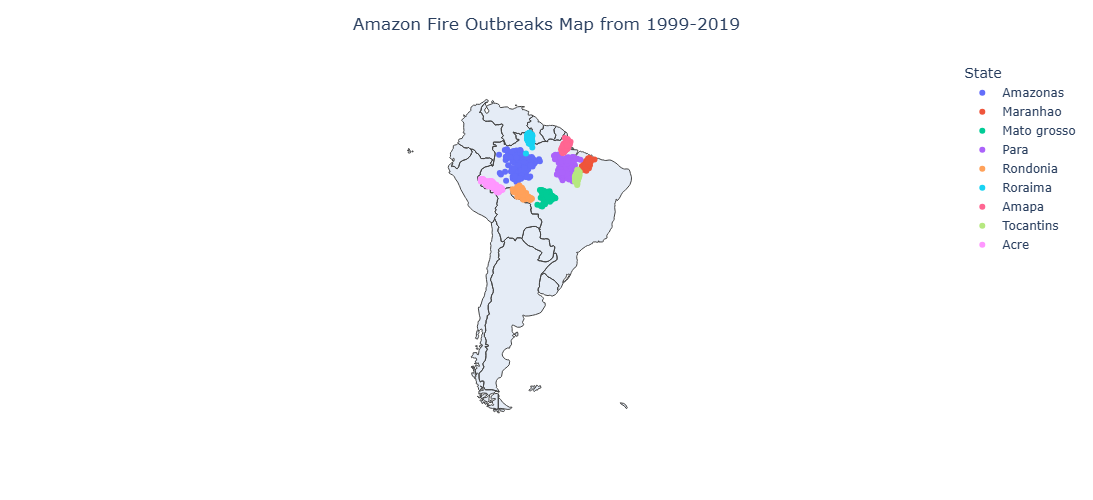

In [163]:
months_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep',
             10:'Oct', 11:'Nov', 12:'Dec'}

fires_df.state = [x.capitalize() for x in fires_df.state]
fires_df['month_str'] = fires_df['month'].map(months_map)
fig = px.scatter_geo(fires_df, lat='latitude',lon='longitude', color='state', 
                     hover_data=['state', 'year', 'month_str', 'firespots'], width=800, height=500)
fig.update_layout(title = 'Amazon Fire Outbreaks Map from 1999-2019', title_x=0.5, geo_scope='south america',
                 legend_title_text='State')
fig.show()

#### Now we look at fire frequency for each state over the years. Next we'll break occurences for each state on a monthly basis!

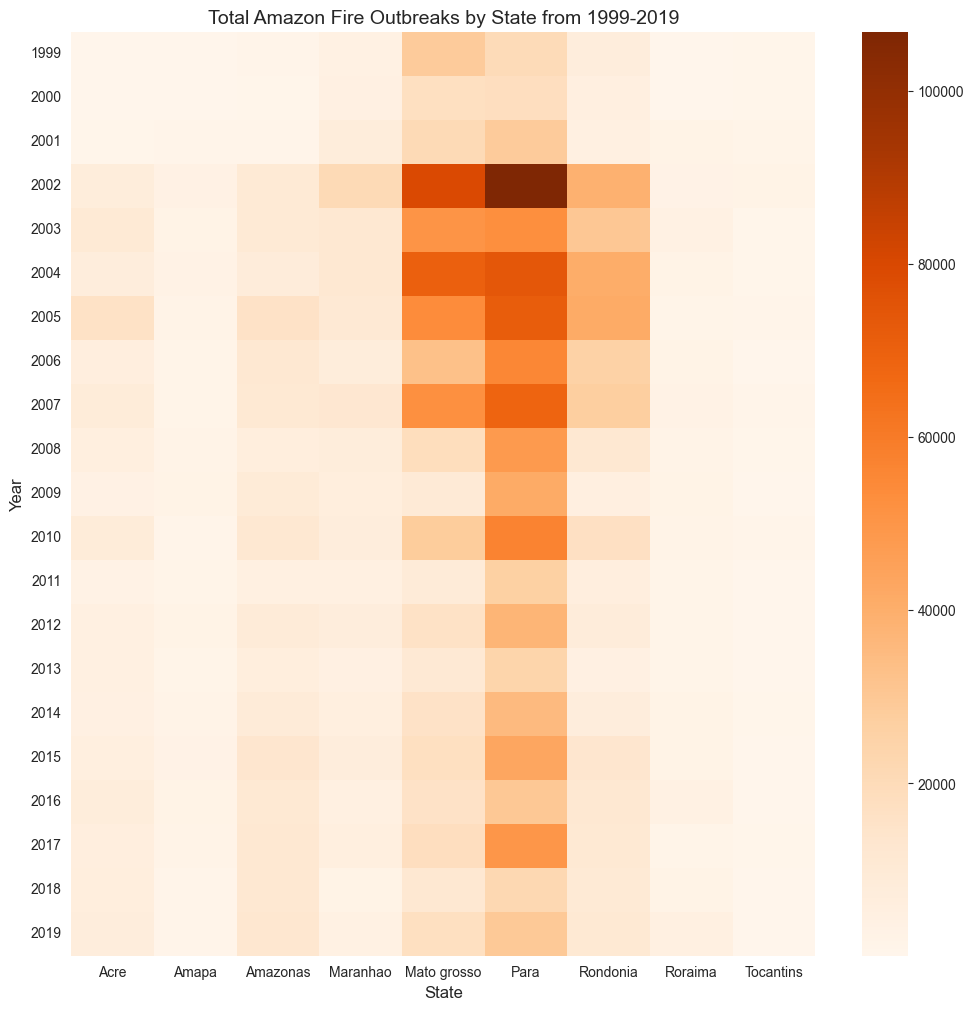

In [164]:
fig, ax = plt.subplots(figsize=(12,12))
fires_piv = pd.pivot_table(fires_df, values='firespots',index=['year'], columns=['state'], 
                     aggfunc=np.sum, fill_value=0)
ax = sns.heatmap(fires_piv, cmap='Oranges')
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_title('Total Amazon Fire Outbreaks by State from 1999-2019', fontsize=14)
plt.setp(ax.yaxis.get_majorticklabels(), rotation=0)
plt.show()

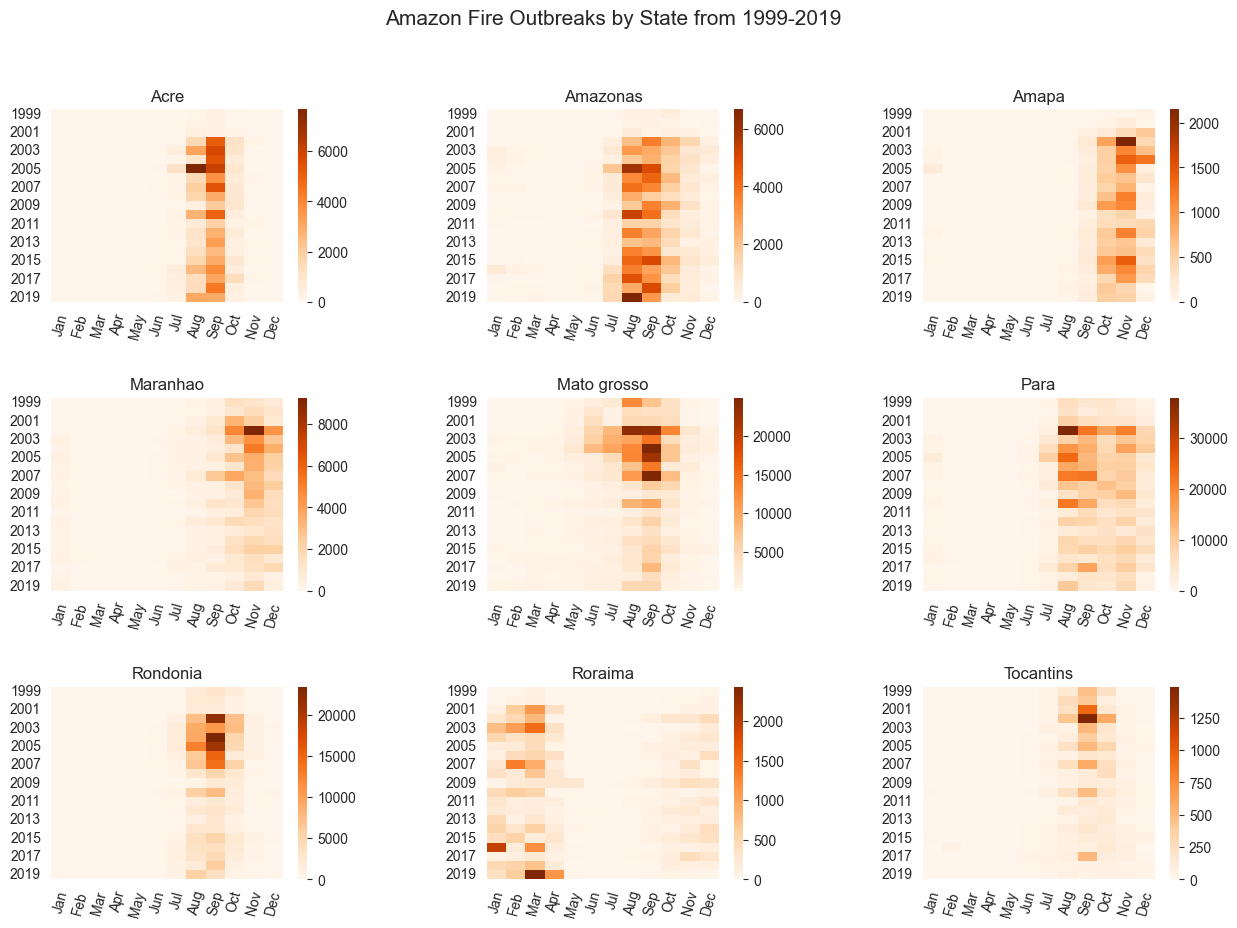

In [165]:
fig, ax = plt.subplots(3,3, figsize=(15,10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.suptitle('Amazon Fire Outbreaks by State from 1999-2019', fontsize=15)
# Make a pivot table for fires in each state
states_piv = pd.pivot_table(fires_df, values='firespots',index=['year'], columns=['state', 'month'], 
                            aggfunc=np.sum, fill_value=0)
states_list = ['Acre', 'Amazonas', 'Amapa', 'Maranhao', 'Mato grosso', 'Para', 'Rondonia', 'Roraima', 'Tocantins']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i in range(3):
    for j in range(3):
        col = states_list[i*3+j]
        piv_plot = states_piv[[col]]
        sns.heatmap(piv_plot, cmap='Oranges', xticklabels=months, ax=ax[i,j])
        ax[i,j].set_xlabel('')
        ax[i,j].set_ylabel('')
        ax[i,j].set_title(col)
        plt.setp(ax[i,j].xaxis.get_majorticklabels(), rotation=75)

#### We can see that different states show a different number of fire outbreaks throughout the year

#### Total firespots across all 9 states throughout the year

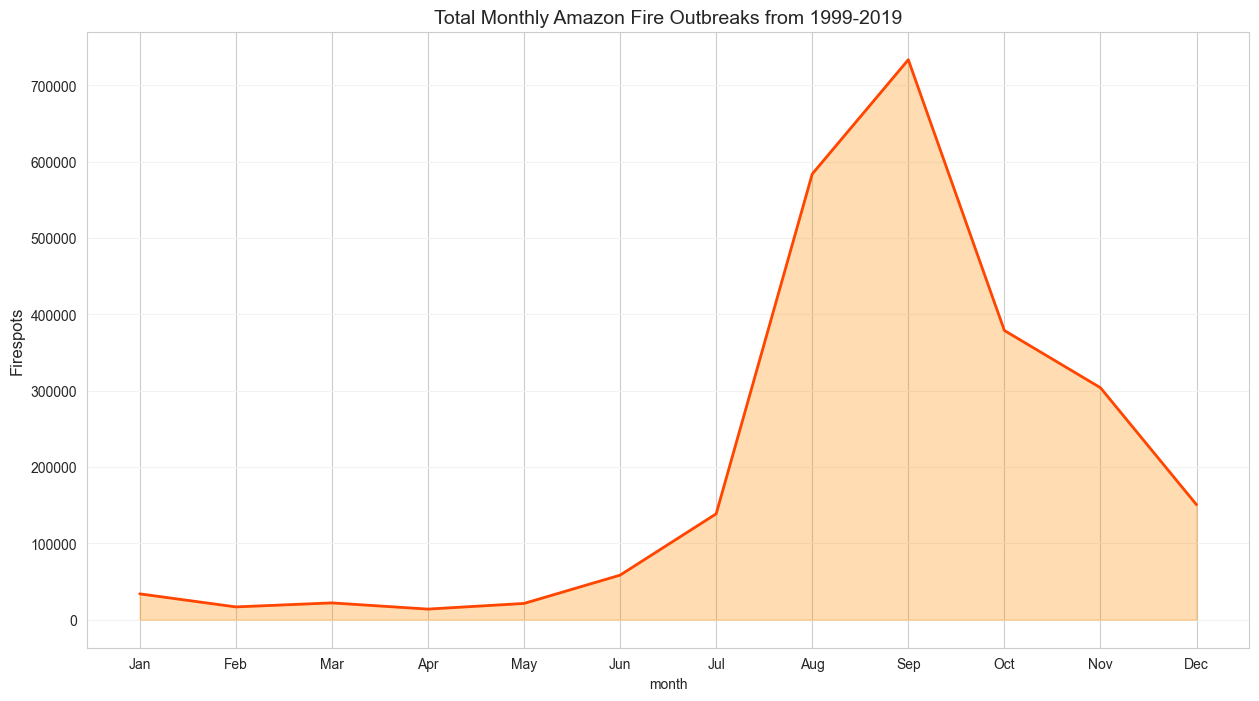

In [166]:
fig, ax = plt.subplots(figsize=(15,8))
months_piv = pd.pivot_table(fires_df, values='firespots',index=['month'], aggfunc=np.sum, fill_value=0)
months_piv.plot(xticks=range(1,13,1), linewidth=2, color='orangered', legend=False, ax=ax)
ax.set_ylabel('Firespots', fontsize=12)
ax.set_title('Total Monthly Amazon Fire Outbreaks from 1999-2019', fontsize=14)
ax.set_xticklabels(months_map.values())
ax.grid(axis='y', color='0.95')


# Add fill underneath
ax.fill_between(
    months_piv.index,
    months_piv['firespots'],
    color='darkorange',
    alpha=0.3   # controls transparency
)

plt.show()

#### Now we plot trend lines for individual states to see firespot occurrences over the years  

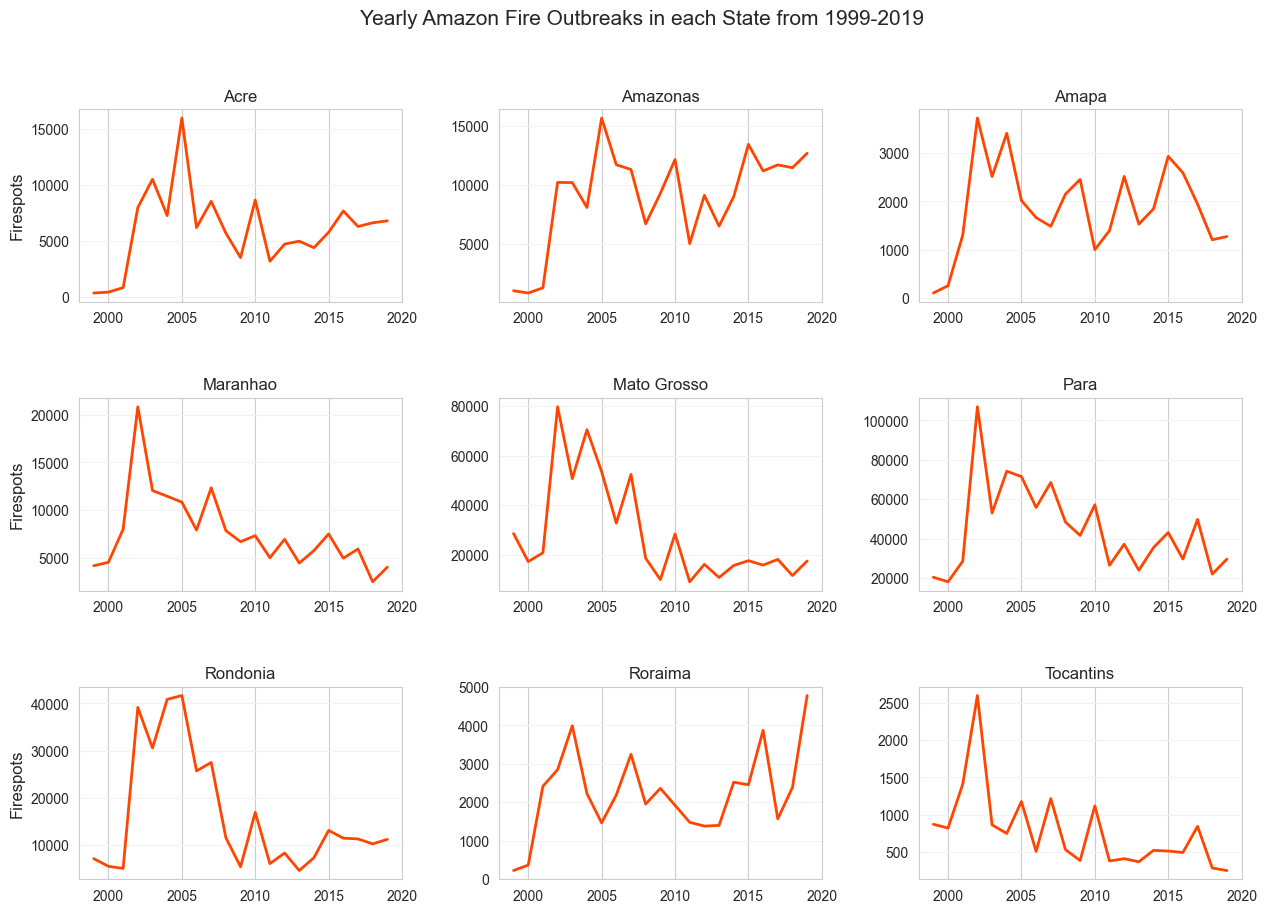

In [167]:
fig, ax = plt.subplots(3,3, figsize=(15,10))
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.suptitle('Yearly Amazon Fire Outbreaks in each State from 1999-2019', fontsize=15)
for i in range(3):
    for j in range(3):
        col = states_list[i*3+j]
        piv_plot = fires_piv[[col]]
        ax[i,j].plot(piv_plot.index, piv_plot[col], linewidth=2, color='orangered')
        ax[i,j].set_ylabel('Firespots', fontsize=12)
        ax[i,j].set_title(states[i*3+j])
        ax[i,j].grid(axis='y', color='0.95')
        if (j>0):
             ax[i,j].set(ylabel='')

#### Plotting the trend in firespots in all 9 states over the years 1999-2019

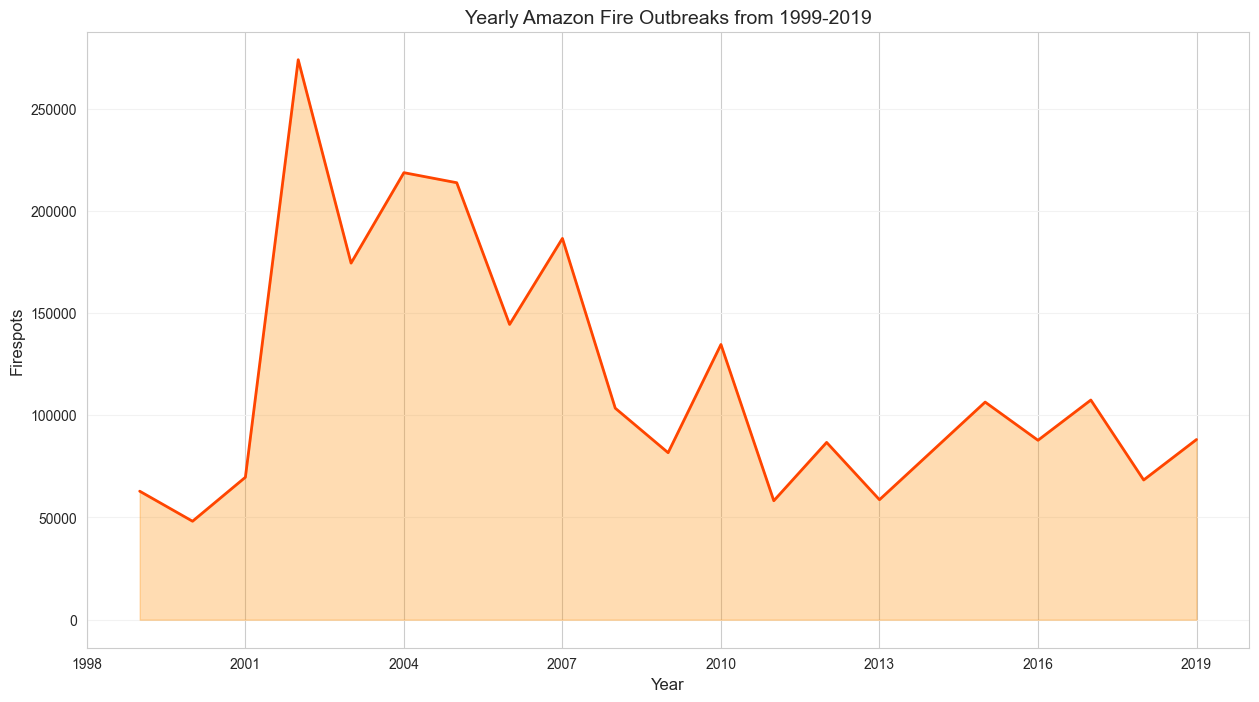

In [168]:
fig, ax = plt.subplots(figsize=(15,8))
total_fires_piv = pd.pivot_table(fires_df, values='firespots',index=['year'], 
                     aggfunc=np.sum, fill_value=0)
total_fires_piv.plot(linewidth=2, color='orangered', legend=False, ax=ax)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Firespots', fontsize=12)
ax.set_title('Yearly Amazon Fire Outbreaks from 1999-2019', fontsize=14)
ax.grid(axis='y', color='0.95')

# Add fill underneath
ax.fill_between(
    total_fires_piv.index,
    total_fires_piv['firespots'],
    color='darkorange',
    alpha=0.3   # controls transparency
)
plt.show()

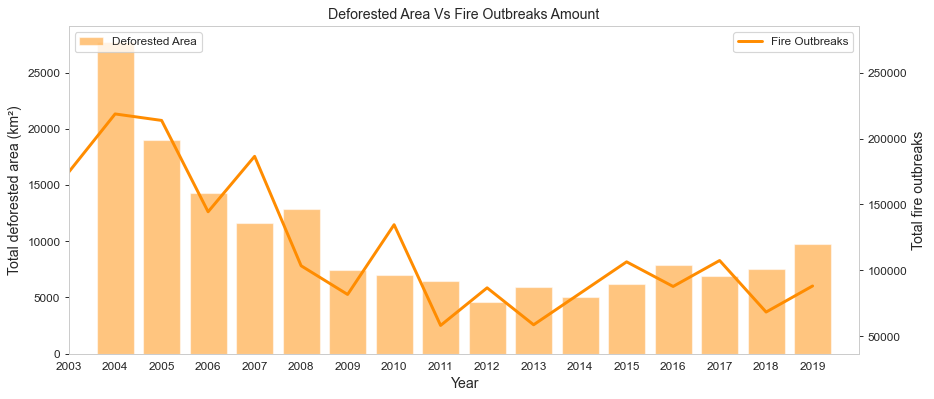

In [169]:
fig, ax = plt.subplots(figsize=(12,5), dpi=85)
sns.set_style("whitegrid")

ax.bar(x, deforest_df['Total'], color='darkorange', alpha=0.5, label='Deforested Area')
plt.grid(False)
ax.legend(loc="upper left")
ax.set_ylabel("Total deforested area (km²)", size="large")
ax.set_xlabel("Year", size="large")
ax.set_title("Deforested Area Vs Fire Outbreaks Amount")
#ax.grid(axis='x')

ax2 = ax.twinx()
sns.lineplot(x=total_fires_piv.index, y=total_fires_piv['firespots'], estimator='sum', color='darkorange', errorbar=None, ax=ax2, label='Fire Outbreaks', lw=2.5)
ax2.set_xticks(ticks=list(range(2003, 2020)))
ax2.set_xlim(2003, 2020)
ax2.set_ylabel("Total fire outbreaks", size="large")
plt.grid(False)
ax2.legend();

#### Deforested area will often see a slight spike after a spike in fire outbreaks. Let's see if there's a correlation. 

In [170]:
deforest_df

,Ano/Estados,AC,AM,AP,MA,MT,PA,RO,RR,TO,Total,Total_cumsum
0,2004,728,1232,46,755,11814,8870,3858,311,158,27772,27772
1,2005,592,775,33,922,7145,5899,3244,133,271,19014,46786
2,2006,398,788,30,674,4333,5659,2049,231,124,14286,61072
3,2007,184,610,39,631,2678,5526,1611,309,63,11651,72723
4,2008,254,604,100,1271,3258,5607,1136,574,107,12911,85634
5,2009,167,405,70,828,1049,4281,482,121,61,7464,93098
6,2010,259,595,53,712,871,3770,435,256,49,7000,100098
7,2011,280,502,66,396,1120,3008,865,141,40,6418,106516
8,2012,305,523,27,269,757,1741,773,124,52,4571,111087
9,2013,221,583,23,403,1139,2346,932,170,74,5891,116978


In [171]:
total_fires_piv

,firespots
year,
1999,62858
2000,48168
2001,69675
2002,273873
2003,174400
2004,218637
2005,213720
2006,144422
2007,186480


In [172]:
# Keep yearly fire data
comb = total_fires_piv[total_fires_piv.index > 2003].copy()

# Get deforestation per year
def_area = deforest_df.groupby('Ano/Estados')['Total'].sum()

# Align by year
comb['Total'] = def_area.reindex(comb.index)

# Correlation works
print(comb[['firespots', 'Total']].corr())

           firespots     Total
firespots   1.000000  0.833778
Total       0.833778  1.000000


#### Correlation of 0.833778

# 4. El Nino and La Nina Compared to Deforested Area and Fire Outbreaks

#### Revisit the data 

In [173]:
climate_df.head()

,start year,end year,phenomenon,severity,severity_height
13,1999,2000,La Nina,Strong,3
7,2000,2001,La Nina,Weak,1
4,2002,2003,El Nino,Moderate,2
0,2004,2005,El Nino,Weak,1
8,2005,2006,La Nina,Weak,1


In [174]:
#create a new column with alpha for the graph
alpha_map = {
    "Weak": 1,
    "Moderate": 2,
    "Strong": 3,
    "Very Strong": 4
}

climate_df['alpha'] = climate_df["severity"].map(alpha_map)

In [175]:
#separating between El Niño and La Niña
el_nino_records = climate_df[climate_df['phenomenon'] == 'El Nino'].copy()
la_nina_records = climate_df[climate_df['phenomenon'] == 'La Nina'].copy()

In [176]:
el_nino_records['alpha'] = el_nino_records['alpha'] / 4
la_nina_records['alpha'] = la_nina_records['alpha'] / 4

#### Now we analyze fire outbreaks vs. El Nino and La Nina events

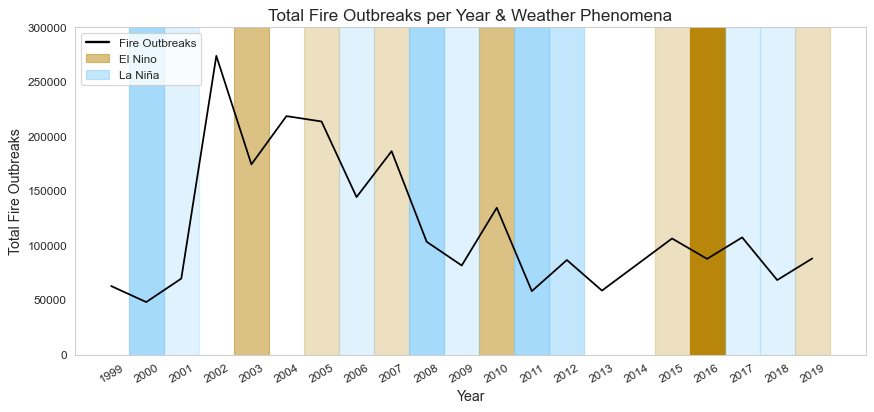

In [177]:
fig, ax = plt.subplots(figsize=(12,5), dpi=85)
sns.set_style("whitegrid")

# Ploting El Niño and La Niña
for i, row in el_nino_records.iterrows(): #generate a list of rows
    ax.axvspan(row["start year"]+0.5, row["end year"]+0.5, alpha=row["alpha"], color='darkgoldenrod', edgecolor=None, label='El Niño')

for i, row in la_nina_records.iterrows(): #generate a list of rows
    ax.axvspan(row["start year"]+0.5, row["end year"]+0.5, alpha=row["alpha"], color='lightskyblue', edgecolor=None, label='La Niña')


    
# Ploting the line
sns.lineplot(x=total_fires_piv.index, y=total_fires_piv['firespots'], estimator='sum', color="black", errorbar=None, ax=ax)
ax.grid(False)

plt.xticks(ticks=list(range(1999, 2020)), rotation=30)

plt.title("Total Fire Outbreaks per Year & Weather Phenomena", size="x-large")
plt.xlabel('Year', size="large")
plt.ylabel('Total Fire Outbreaks', size="large")

legend_elements = [Line2D([0], [0], color='black', lw=2, label='Fire Outbreaks'),
                   Patch(facecolor='darkgoldenrod', edgecolor='darkgoldenrod', label='El Nino', alpha=0.5),
                   Patch(facecolor='lightskyblue', edgecolor='lightskyblue', label='La Niña', alpha=0.5)]

ax.legend(handles=legend_elements)
ax.set_ylim(0,300000);

#### The above figure maps fire outbreaks against El Nino and La Nina phenomenons (weak, moderate, strong, and very strong). We can see a general trend in an increase of fire outbreaks during El Nino years with a couple exceptions and vice versa for La Nina years (also with a couple exceptions). There may not be a causal relationship here however, despite indication of slight correlation between El Nino years and fire outbreaks.

In [178]:
deforest_df

,Ano/Estados,AC,AM,AP,MA,MT,PA,RO,RR,TO,Total,Total_cumsum
0,2004,728,1232,46,755,11814,8870,3858,311,158,27772,27772
1,2005,592,775,33,922,7145,5899,3244,133,271,19014,46786
2,2006,398,788,30,674,4333,5659,2049,231,124,14286,61072
3,2007,184,610,39,631,2678,5526,1611,309,63,11651,72723
4,2008,254,604,100,1271,3258,5607,1136,574,107,12911,85634
5,2009,167,405,70,828,1049,4281,482,121,61,7464,93098
6,2010,259,595,53,712,871,3770,435,256,49,7000,100098
7,2011,280,502,66,396,1120,3008,865,141,40,6418,106516
8,2012,305,523,27,269,757,1741,773,124,52,4571,111087
9,2013,221,583,23,403,1139,2346,932,170,74,5891,116978


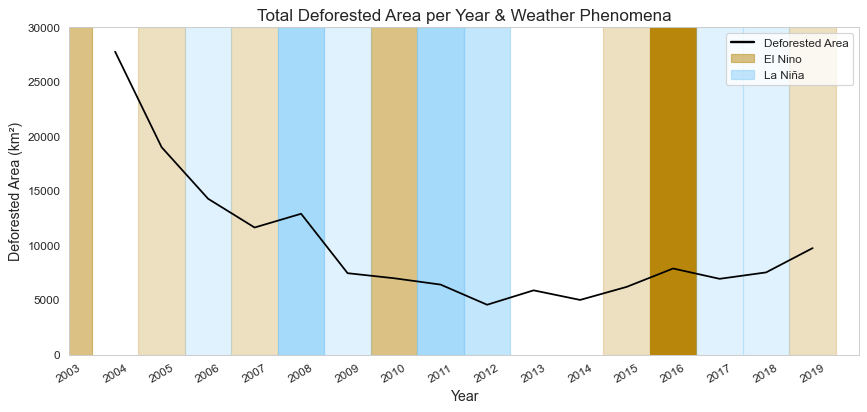

In [179]:

fig, ax = plt.subplots(figsize=(12,5), dpi=85)
sns.set_style("whitegrid")
for i, row in el_nino_records.iterrows(): #generate a list of rows
    ax.axvspan(row["start year"]+0.5, row["end year"]+0.5, alpha=row["alpha"], color='darkgoldenrod', edgecolor=None, label='El Niño')

for i, row in la_nina_records.iterrows(): #generate a list of rows
    ax.axvspan(row["start year"]+0.5, row["end year"]+0.5, alpha=row["alpha"], color='lightskyblue', edgecolor=None, label='La Niña')

sns.lineplot(x=deforest_df['Ano/Estados'], y=deforest_df['Total'], estimator='sum', color="black", errorbar=None, ax=ax)
ax.grid(False)

plt.xticks(ticks=list(range(2003, 2020)), rotation=30)
ax.set_xlim(2003, 2020)

plt.title("Total Deforested Area per Year & Weather Phenomena", size="x-large")
plt.xlabel('Year', size="large")
plt.ylabel('Deforested Area (km²)', size="large")

legend_elements = [Line2D([0], [0], color='black', lw=2, label='Deforested Area'),
                   Patch(facecolor='darkgoldenrod', edgecolor='darkgoldenrod', label='El Nino', alpha=0.5),
                   Patch(facecolor='lightskyblue', edgecolor='lightskyblue', label='La Niña', alpha=0.5)]

ax.legend(handles=legend_elements)
ax.set_ylim(0,30000);

#### Here we don't see much of a correlation between El Nino and La Nina phenomena and deforestation trends.